# 01 — Exploratory Data Analysis (Store Sales)

**Goal of this notebook:** understand the data well enough that every later modeling choice is *motivated by evidence*, not guessed. It produces no model — it produces insight and verified data integrity.

We read the raw competition CSVs through the small `src/data.py` loaders (so the notebook stays thin and the loading logic is reused and tested in one place), then work through the data in sections: shapes & integrity first, then trend, seasonality, calendar/holidays, promotions/oil, and anomalies.

Run it top-to-bottom from a fresh kernel.

## Section 1 — Load the data & confirm what we're working with

Before any plot or model we answer one question: **is the data exactly what every later step assumes?**

We load all seven CSVs, print each one's shape and (where it has a `date`) its date range, then *assert* the four headline facts of this competition:

- **54** stores
- **33** product families
- **54 × 33 = 1,782** time series (one per store × family)
- training history spans **2013-01-01 → 2017-08-15**

Why assert and not just print? A printed number you read once; an `assert` checks the number on *every* run and fails loudly the moment the data changes underneath us. That turns a silent corruption (a re-downloaded CSV with a different shape) into an obvious error instead of a wrong model.

In [1]:
import sys
from pathlib import Path

# The kernel's working directory is `notebooks/`, but our reusable code lives in the
# project's `src/` package one level up. Put the repo root on the import path so
# `import src.data` works whether the kernel started in the repo root or in notebooks/.
here = Path.cwd()

repo_root = here if (here / "src").exists() else here.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data as data

print("repo root:", repo_root)

repo root: D:\AIO\M01\Conquer\TimeSeries


In [2]:
# Load every raw CSV through the loaders in src/data.py (read-only source of truth).
train = data.load_train()
test = data.load_test()
stores = data.load_stores()
transactions = data.load_transactions()
oil = data.load_oil()
holidays = data.load_holidays()
sample_submission = data.load_sample_submission()

# Shape of each table; date range for the ones that carry a calendar.
frames = {
    "train": train,
    "test": test,
    "stores": stores,
    "transactions": transactions,
    "oil": oil,
    "holidays": holidays,
    "sample_submission": sample_submission,
}

for name, df in frames.items():
    if "date" in df.columns:
        span = f"{df['date'].min().date()} -> {df['date'].max().date()}"
    else:
        span = "(no date column)"
    print(f"{name:18s} shape={str(df.shape):16s} {span}")

train              shape=(3000888, 6)     2013-01-01 -> 2017-08-15
test               shape=(28512, 5)       2017-08-16 -> 2017-08-31
stores             shape=(54, 5)          (no date column)
transactions       shape=(83488, 3)       2013-01-01 -> 2017-08-15
oil                shape=(1218, 2)        2013-01-01 -> 2017-08-31
holidays           shape=(350, 6)         2012-03-02 -> 2017-12-26
sample_submission  shape=(28512, 2)       (no date column)


In [3]:
# Confirm the four headline facts. Each assert fails loudly if the data ever shifts;
# the print line lets us read the numbers we just checked.
n_stores = stores["store_nbr"].nunique()
n_families = train["family"].nunique()
n_series = train.groupby(["store_nbr", "family"], observed=True).ngroups
train_start = train["date"].min().date()
train_end = train["date"].max().date()

assert n_stores == 54, f"expected 54 stores, got {n_stores}"
assert n_families == 33, f"expected 33 families, got {n_families}"
assert n_series == 1782, f"expected 1782 series (54x33), got {n_series}"
assert str(train_start) == "2013-01-01", f"unexpected train start {train_start}"
assert str(train_end) == "2017-08-15", f"unexpected train end {train_end}"

print(f"stores   : {n_stores}")
print(f"families : {n_families}")
print(f"series   : {n_series}  (= {n_stores} x {n_families})")
print(f"train    : {train_start} -> {train_end}")
print("\nAll headline counts confirmed.")

stores   : 54
families : 33
series   : 1782  (= 54 x 33)
train    : 2013-01-01 -> 2017-08-15

All headline counts confirmed.


**What this tells us / what's next:** the data is intact and matches expectations — 1,782 daily series over ~4.6 years, with a fixed 16-day forecast horizon (test: 2017-08-16 → 2017-08-31). One caveat the shapes already hint at: `train` has far fewer rows than `1782 series × every calendar day`, because the store is closed on a few days (e.g. Dec 25) and those rows are simply *absent* rather than recorded as zero. A second thing the spans reveal: `oil` and the test rows (with `onpromotion`) reach 2017-08-31, but `transactions` stops at the train end (2017-08-15) — so transactions has **no coverage of the forecast horizon** and can only ever be used as a *lagged* feature, never same-day. The next section restores a complete daily calendar per series so that lag and seasonality features count days correctly.

## Section 2 — Make the calendar gap-free

Section 1 flagged that `train` is *missing rows* for days the store was closed (e.g. every Dec 25) — those days are simply absent rather than recorded as zero. Here we fix that with `reindex_series_gapfree` (from `src/data.py`): it reindexes every series onto a complete daily calendar and fills the inserted closed days with `sales = 0`, marking them `was_closed=True`.

Then we run `assert_gapfree` (from `src/validation.py`) to **prove** the result has no missing or duplicate days, and we cross-check the row count against the full grid (1,782 series × every calendar day). This is the integrity guarantee every later lag/seasonality feature depends on — so we verify it before plotting anything.

In [4]:
# Restore a complete daily calendar per series, then PROVE there are no gaps.
from src.data import reindex_series_gapfree
from src.validation import assert_gapfree

before_rows = len(train)
train_gf = reindex_series_gapfree(train)
after_rows = len(train_gf)
added = after_rows - before_rows

# Raises loudly if ANY series still has a missing day or a duplicate day.
assert_gapfree(train_gf)

# Cross-check the size: a full grid is n_series x every calendar day in the range.
n_days = (train["date"].max() - train["date"].min()).days + 1
expected_rows = n_series * n_days  # n_series defined in Section 1

print(f"before : {before_rows:,} rows")
print(f"after  : {after_rows:,} rows")
print(f"added  : {added:,} closed-day rows")
print(f"expected (1782 series x {n_days} days) = {expected_rows:,}")
assert after_rows == expected_rows, "reindexed row count does not match the full grid"

# Confirm the synthesized closed-day rows were filled with sales = 0 (true and leak-safe).
closed = train_gf[train_gf["was_closed"]]
print(f"\nclosed-day rows flagged : {len(closed):,}")
print(f"max sales on closed days: {closed['sales'].max()}  (must be 0.0)")
assert (closed["sales"] == 0).all(), "closed-day rows must have sales = 0"

print("\nGap-free calendar confirmed; closed days filled with sales = 0.")

before : 3,000,888 rows
after  : 3,008,016 rows
added  : 7,128 closed-day rows
expected (1782 series x 1688 days) = 3,008,016

closed-day rows flagged : 7,128
max sales on closed days: 0.0  (must be 0.0)

Gap-free calendar confirmed; closed days filled with sales = 0.


In [5]:
# `train` is *missing rows* for days the store was closed, 
# so we reindex to a gap-free calendar in `train_gf`. 
# The new rows have `was_closed = True` and `sales = 0`, 
# which is correct and leak-safe.
train_gf

,store_nbr,family,date,id,sales,onpromotion,was_closed
0,1,AUTOMOTIVE,2013-01-01,0.0,0.0,0,False
1,1,AUTOMOTIVE,2013-01-02,1782.0,2.0,0,False
2,1,AUTOMOTIVE,2013-01-03,3564.0,3.0,0,False
3,1,AUTOMOTIVE,2013-01-04,5346.0,3.0,0,False
4,1,AUTOMOTIVE,2013-01-05,7128.0,5.0,0,False
...,...,...,...,...,...,...,...
3008011,54,SEAFOOD,2017-08-11,2993627.0,0.0,0,False
3008012,54,SEAFOOD,2017-08-12,2995409.0,1.0,1,False
3008013,54,SEAFOOD,2017-08-13,2997191.0,2.0,0,False
3008014,54,SEAFOOD,2017-08-14,2998973.0,0.0,0,False


**What this tells us / what's next:** every `(store_nbr, family)` series is now a contiguous daily run from 2013-01-01 to 2017-08-15 — the handful of closed days (mostly Dec 25 across the years) are back in the table as genuine zero-sales rows, flagged `was_closed=True`. That matters because the lag and Fourier-seasonality features built in later notebooks count *rows* as days: on the raw data a missing Dec 25 would silently shift every later lag by one day. With the calendar gap-free and the assertion passing, the trend and seasonality views in the next sections rest on a sound daily index.

Next: Section 3 plots the overall and per-family **trend** (aggregate daily sales over time).

## Section 3 — Trend over time

The first thing to understand about the series is its **trend**: does sales drift up, down, or sideways across the ~4.6 years of history? Trend is usually the single largest, most predictable component, so the deterministic model in Stage 2 will model it explicitly.

We look at it two ways:

1. **Overall** — total sales across all 1,782 series per day, with a 28-day rolling mean to see the underlying drift through the weekly noise.
2. **Per family** — monthly total sales for each of the 33 families, on a small-multiples grid, since families differ enormously in scale and may not all trend the same way.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

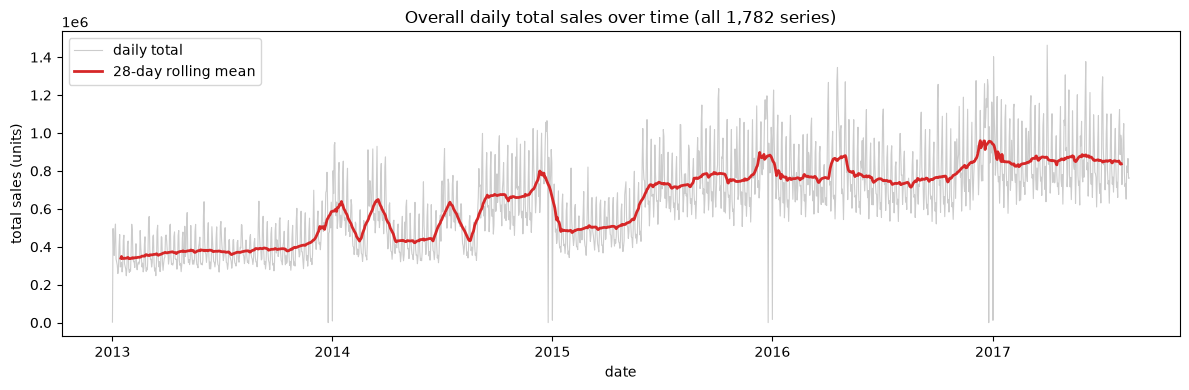

In [7]:
# Overall trend: total sales across all 1,782 series per day. The raw daily total has a
# strong weekly sawtooth, so we overlay a 28-day centered rolling mean to expose the
# underlying trend (growth over the years) through that noise.
daily_total = train_gf.groupby("date")["sales"].sum()
roll = daily_total.rolling(28, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_total.index, daily_total.values, color="0.8", lw=0.8, label="daily total")
ax.plot(roll.index, roll.values, color="C3", lw=2, label="28-day rolling mean")
ax.set_title("Overall daily total sales over time (all 1,782 series)")
ax.set_xlabel("date")
ax.set_ylabel("total sales (units)")
ax.legend()
fig.tight_layout()
plt.show()

In [8]:

# Per-family trend: monthly total sales per family. Resampling to month-start ("MS")
# smooths away the weekly/holiday noise so the underlying trend shape is visible.
# Each family gets its own y-scale because scales differ by orders of magnitude
# (GROCERY I dwarfs e.g. BOOKS), so a shared axis would flatten the small families.
fam_month = (
    train_gf.set_index("date")
    .groupby("family", observed=True)["sales"]
    .resample("MS")
    .sum()
    .unstack(0)  # rows = month, columns = family
)


In [9]:
# resample is a time-grouping operation — it can only run while the dates are still present in the index. 
# So we set the date as the index first, then group by family, then resample within each family group.
# Think of .resample("MS").sum() as "bucket by month, then total each bucket".
print(train_gf.set_index("date").groupby("family", observed=True)["sales"].resample("MS").sum())
print("===================================")
# the result shows each pair (family, date). . The MultiIndex has two levels in a fixed order: level 0 = family, level 1 = date
# unstack(N) just picks which level by that number. The level you name becomes the columns; the other stays as rows
print(fam_month.head(10))  # first 10 rows of the monthly totals per family

print(fam_month.columns.tolist())

family      date      
AUTOMOTIVE  2013-01-01     6557.000000
            2013-02-01     7220.000000
            2013-03-01     7635.000000
            2013-04-01     7485.000000
            2013-05-01     9034.000000
                              ...     
SEAFOOD     2017-04-01    36221.881986
            2017-05-01    39666.393999
            2017-06-01    31365.775991
            2017-07-01    35040.687006
            2017-08-01    16154.549020
Name: sales, Length: 1848, dtype: float64
family      AUTOMOTIVE  BABY CARE  BEAUTY  BEVERAGES  BOOKS   BREAD/BAKERY  \
date                                                                         
2013-01-01      6557.0        0.0  4019.0  1670653.0    0.0  549778.856175   
2013-02-01      7220.0        0.0  3747.0  1508254.0    0.0  499809.403770   
2013-03-01      7635.0        0.0  3901.0  1822220.0    0.0  594024.801690   
2013-04-01      7485.0        0.0  3670.0  1743121.0    0.0  568623.219100   
2013-05-01      9034.0        0.0  371

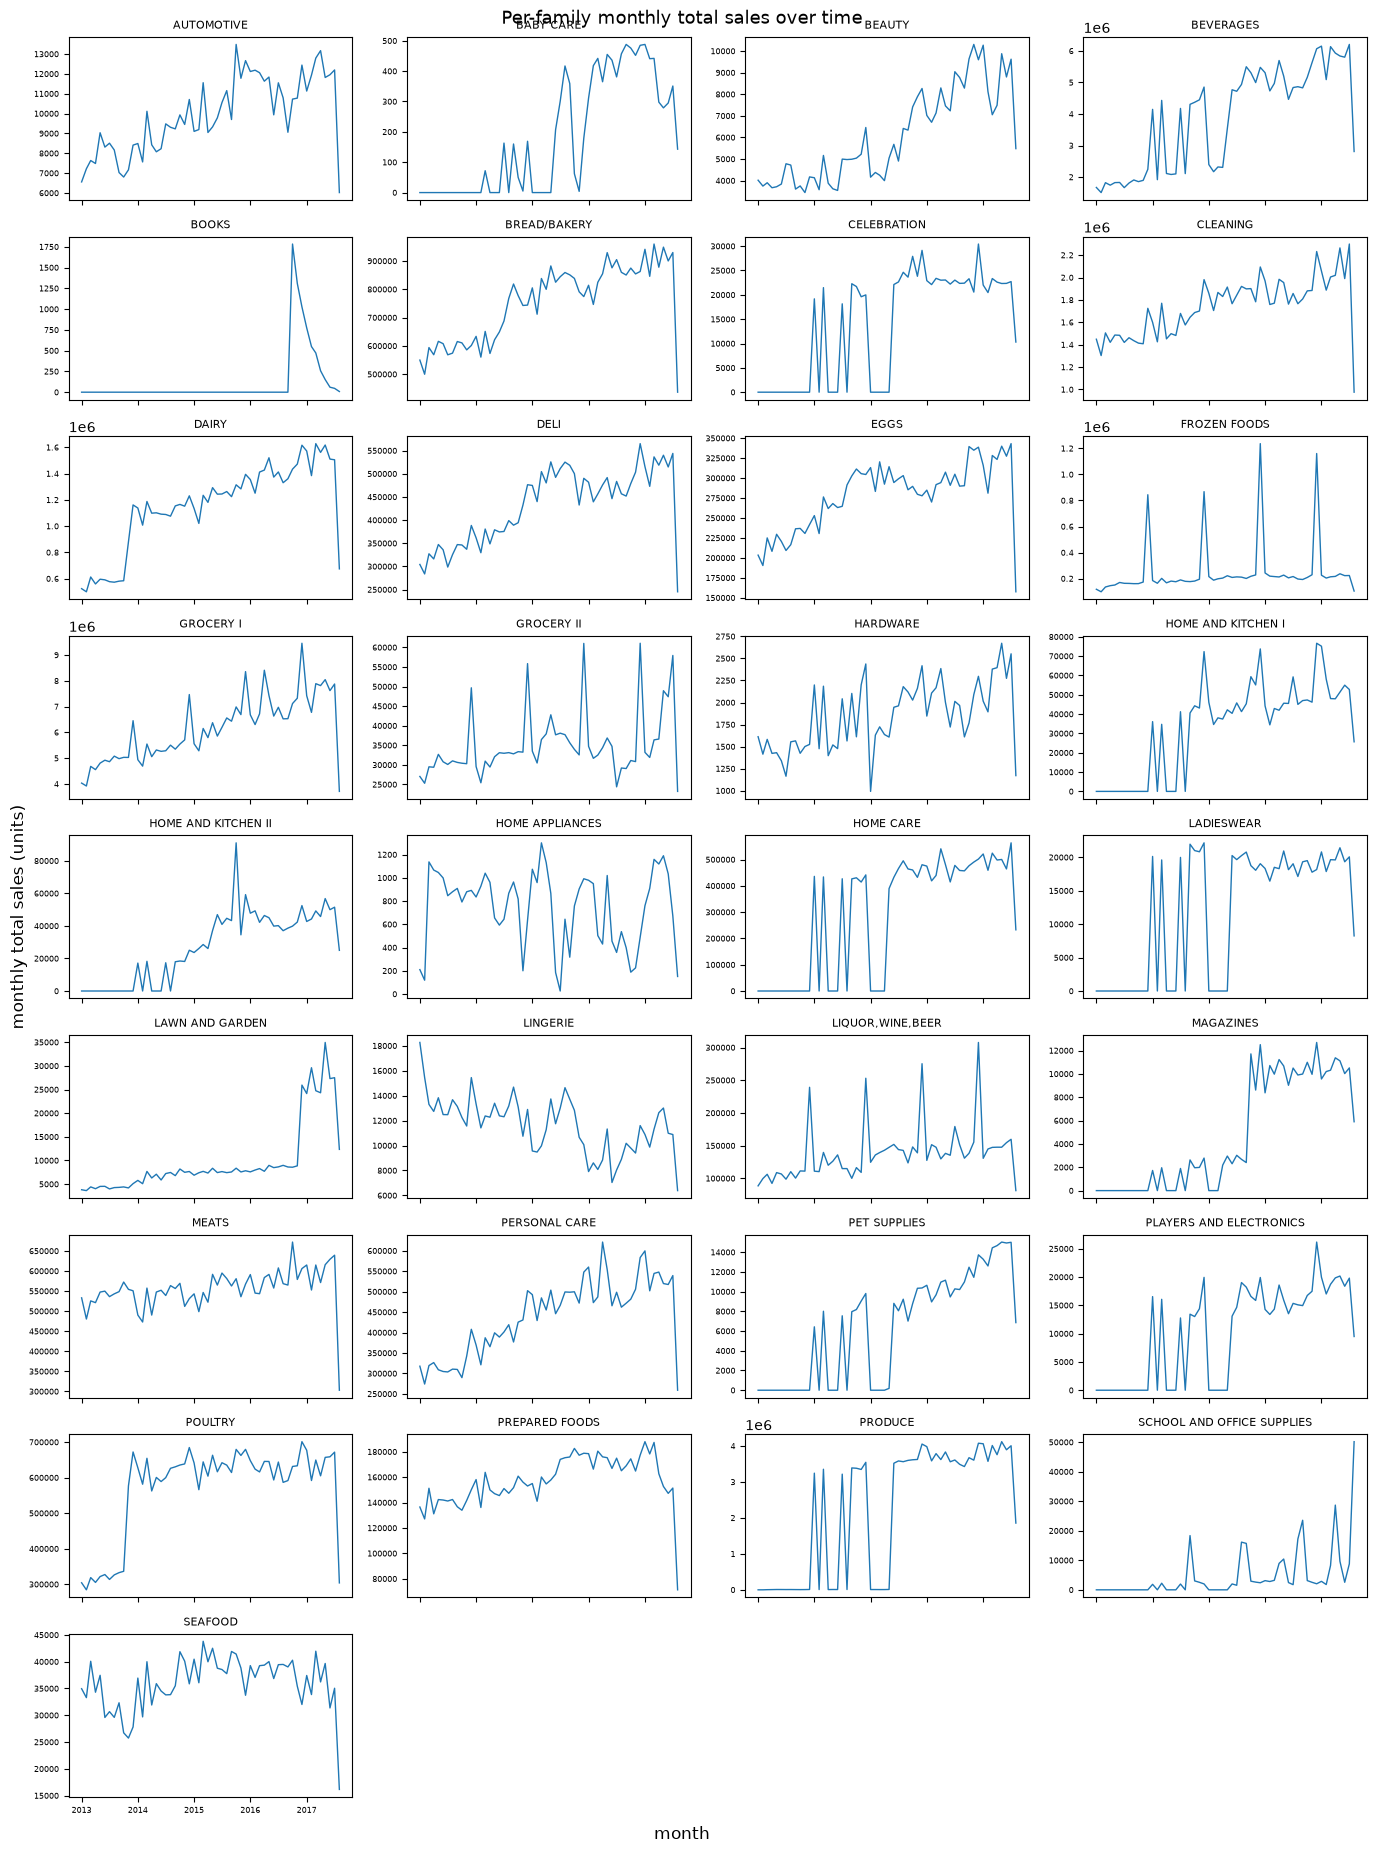

In [10]:

families = list(fam_month.columns)
ncols = 4
nrows = int(np.ceil(len(families) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.1 * nrows), sharex=True)
axes = axes.ravel()

for ax, fam in zip(axes, families):
    ax.plot(fam_month.index, fam_month[fam], lw=1, color="C0")
    ax.set_title(fam, fontsize=8)
    ax.tick_params(labelsize=6)
for ax in axes[len(families):]:  # hide unused panels in the grid
    ax.set_visible(False)

fig.suptitle("Per-family monthly total sales over time", fontsize=13)
fig.supxlabel("month")
fig.supylabel("monthly total sales (units)")
fig.tight_layout()
plt.show()

**What this tells us / what's next (implications for the trend stage):**

- **Sales grow strongly over time.** The mean daily total roughly doubles from ~386k (2013) to ~856k (2017) — but the growth *decelerates* (large early jumps, smaller later ones). So a **trend term is essential**, and a purely straight line will slightly over/under-shoot at the ends; allowing mild curvature (a higher-order or spline trend) is worth trying in the deterministic stage.
- **Families live on wildly different scales.** The top 6 families are ~83% of all sales (GROCERY I dominates), while many families are tiny. A single global level would be swamped by the big families, so the trend should be captured **per series/family**, and modeling the target in `log1p` space keeps the small families from being ignored.
- **The shape is shared but the size isn't.** Most families show the same broad upward drift plus a seasonal wiggle — exactly the structure a deterministic *trend + seasonality* model is built for. That motivates Stage 2 (deterministic) directly after the seasonal-naive baseline.

Next: Section 4 looks at **seasonality** (day-of-week and annual patterns) to choose the Fourier orders for that deterministic model.

## Section 4 — Weekly and annual seasonality

Trend tells us the slow drift; **seasonality** is the repeating calendar pattern layered on top of it. Two cycles matter for daily retail sales:

1. **Weekly** — do some weekdays consistently sell more than others? We average the total daily sales by day-of-week.
2. **Annual** — does the year have a recurring shape (e.g. a December holiday peak)? We average the total by calendar month.

We also include a **periodogram** as a bonus: it decomposes the series into cycles of different lengths and shows which ones carry the most variation, letting the data *confirm* the cycle lengths rather than us assuming them.

The point of this section is concrete: the deterministic model in Stage 2 represents each cycle with **Fourier terms** (pairs of sine/cosine waves). The sharper and more wiggly a cycle is, the more sine/cosine pairs ("harmonics") it needs — so these plots tell us roughly how many to use.

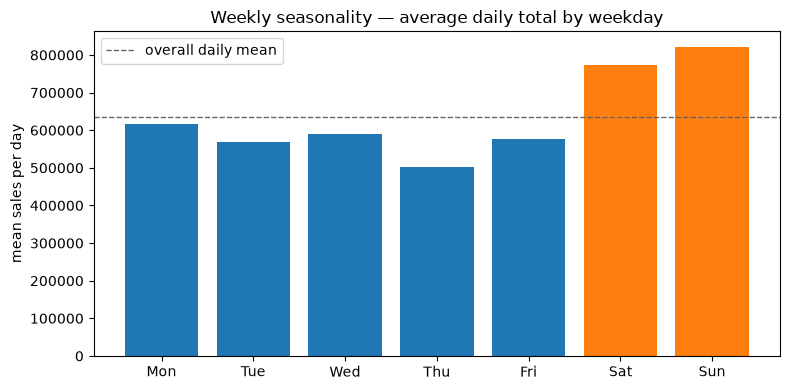

weekend vs weekday mean ratio : 1.39
peak day   : Sun  (821,794)
trough day : Thu  (503,173)


In [11]:
# Weekly seasonality: average daily total for each day of the week.
# daily_total (from Section 3) is a Series indexed by date; .index.dayofweek returns
# Monday=0 ... Sunday=6, so grouping by it averages every Monday together, every
# Tuesday together, and so on.
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly = daily_total.groupby(daily_total.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["C0"] * 5 + ["C1"] * 2          # weekdays blue, weekend orange
ax.bar(dow_names, weekly.values, color=bar_colors)
ax.axhline(daily_total.mean(), color="0.4", ls="--", lw=1, label="overall daily mean")
ax.set_title("Weekly seasonality — average daily total by weekday")
ax.set_ylabel("mean sales per day")
ax.legend()
fig.tight_layout()
plt.show()

ratio = weekly[[5, 6]].mean() / weekly[[0, 1, 2, 3, 4]].mean()
print(f"weekend vs weekday mean ratio : {ratio:.2f}")
print(f"peak day   : {dow_names[weekly.idxmax()]}  ({weekly.max():,.0f})")
print(f"trough day : {dow_names[weekly.idxmin()]}  ({weekly.min():,.0f})")

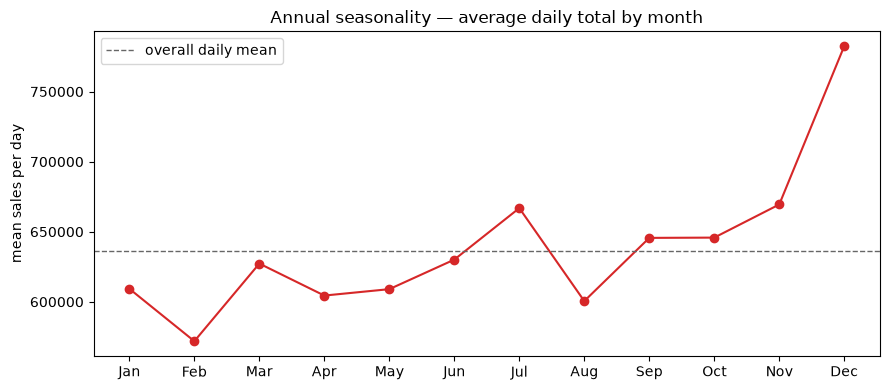

peak month   : Dec  (782,483)
trough month : Feb  (571,895)


In [12]:
# Annual seasonality: average daily total within each calendar month.
# We use the MEAN per month (not the sum) on purpose. Training ends 2017-08-15, so
# Jan-Aug have 5 years of history but Sep-Dec only 4 (2013-2016), and Aug 2017 is a
# half-month. Summing would make the later months look artificially small; the mean
# per day is robust to that uneven coverage.
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly = daily_total.groupby(daily_total.index.month).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(month_names, monthly.values, marker="o", color="C3")
ax.axhline(daily_total.mean(), color="0.4", ls="--", lw=1, label="overall daily mean")
ax.set_title("Annual seasonality — average daily total by month")
ax.set_ylabel("mean sales per day")
ax.legend()
fig.tight_layout()
plt.show()

print(f"peak month   : {month_names[monthly.idxmax() - 1]}  ({monthly.max():,.0f})")
print(f"trough month : {month_names[monthly.idxmin() - 1]}  ({monthly.min():,.0f})")

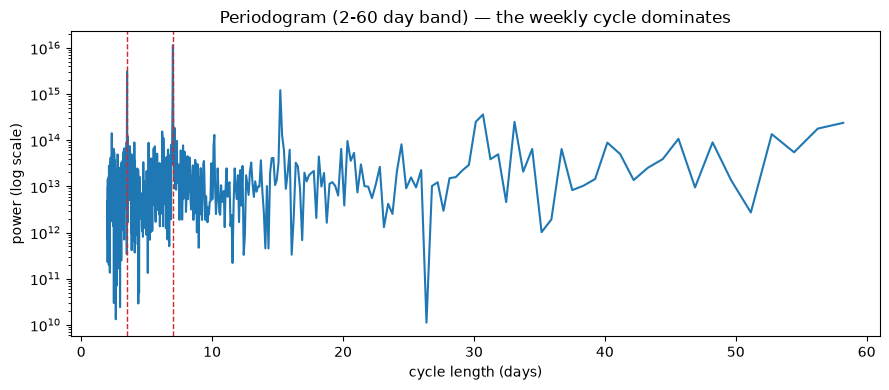

strongest short cycles (days): 7.0, 3.5, 15.2


In [13]:
# (Bonus) Periodogram: which cycle lengths carry the most variation?
# We take the FFT power of the daily total after removing its mean, then look ONLY at
# short cycles (2-60 days). The slow multi-year growth lives at the very lowest
# frequencies and would otherwise dwarf everything, so we zoom in on the seasonal band
# and use a log y-scale to compare spike heights.
x = daily_total.values.astype(float)
x = x - x.mean()                              # drop the constant level (not the trend)
freqs = np.fft.rfftfreq(len(x), d=1.0)        # cycles per day
power = np.abs(np.fft.rfft(x)) ** 2

periods = np.full_like(freqs, np.inf)
periods[1:] = 1.0 / freqs[1:]                 # cycle length in days (skip freq 0)
band = (periods >= 2) & (periods <= 60)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(periods[band], power[band], color="C0")
for p in (7, 3.5):
    ax.axvline(p, color="C3", ls="--", lw=1)
ax.set_title("Periodogram (2-60 day band) — the weekly cycle dominates")
ax.set_xlabel("cycle length (days)")
ax.set_ylabel("power (log scale)")
fig.tight_layout()
plt.show()

top = np.argsort(power[band])[::-1][:3]
print("strongest short cycles (days):",
      ", ".join(f"{periods[band][i]:.1f}" for i in top))

**What this tells us / what's next (implications for the seasonality stage):**

- **A strong weekly cycle is the dominant short-term pattern.** Weekend days (Sat–Sun) run ~40% above the weekday average — Sunday is the peak, Thursday the low. The periodogram backs this up: the biggest short-cycle spike sits at **7 days**, with a clear secondary spike at **3.5 days** (its 2nd harmonic). Because the weekend bump is sharp rather than a smooth sine wave, a single sine/cosine pair can't reproduce it — we'll want roughly **2–3 weekly harmonics** when we add Fourier seasonal terms.
- **A milder annual cycle peaks in December.** The month profile climbs to a clear **December high** and a **February low**, with a summer bump around July. A smooth curve like this needs only **a few annual harmonics (~3–5)**. Note the periodogram *cannot* pin the 365-day cycle cleanly — ~4.6 years spans too few annual cycles to resolve it — so the **month profile is the real evidence** for the annual term.
- **Read the month profile with care.** It is *not* detrended, so it blends the multi-year growth with true seasonality, and the later months carry one fewer year of data (training stops mid-August 2017). Even so, December still tops the chart *despite missing its highest-sales year* — which makes the holiday surge more convincing, not less.
- **Leave the sharp December spike to calendar features, not more harmonics.** Chasing the holiday peak by piling on annual harmonics would overfit a smooth basis to a spiky event; that surge is better handled by the explicit holiday/payday features built in the next section.

Next: Section 5 inspects **calendar and holiday effects** (holiday types/locales and the 15th/month-end paydays) to decide which become model features.

## Section 5 — Calendar & holiday effects

Beyond the smooth weekly and annual cycles, sales are pushed around by specific **calendar
events**. Two kinds matter here:

1. **Holidays & events** (`holidays_events.csv`) — but this is *not* a clean "was it a holiday?"
   table. Holidays can be **transferred** to another date, there are **bridge** days and even
   **work days** (a normally-off day made into a working one), and each holiday has a **locale**
   (National / Regional / Local) that decides which stores it touches.
2. **Paydays** — Ecuadorian public-sector wages are paid on the **15th** and the **last day** of
   each month, a well-known demand driver worth checking.

We first look at the *shape* of the holiday table (so we don't misuse it), then measure the
national-holiday effect on total sales, and finally check the pay-cycle with a day-of-month
profile. The goal is to decide **which calendar signals become model features** — not to build
them here.

rows: 350 | span: 2012-03-02 -> 2017-12-26


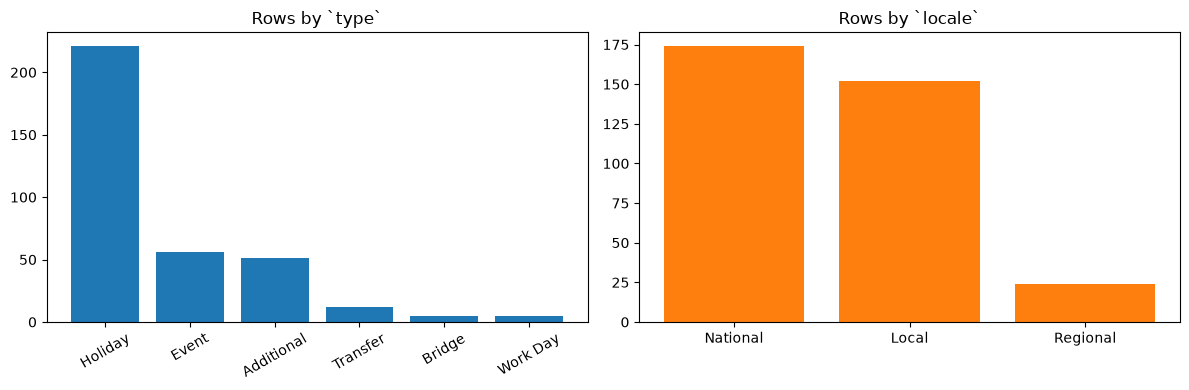


transferred = True (holiday did NOT occur on this date): 12
'Work Day' rows (a normally-off day made into a working day): 5


In [14]:
# holidays_events.csv is NOT a simple "was it a holiday?" table — look at its make-up.
# (holidays was loaded in Section 1.)
print("rows:", len(holidays), "| span:",
      holidays["date"].min().date(), "->", holidays["date"].max().date())

type_counts = holidays["type"].value_counts()
locale_counts = holidays["locale"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(type_counts.index, type_counts.values, color="C0")
ax1.set_title("Rows by `type`")
ax1.tick_params(axis="x", rotation=30)
ax2.bar(locale_counts.index, locale_counts.values, color="C1")
ax2.set_title("Rows by `locale`")
fig.tight_layout()
plt.show()

# The trap: some rows move a holiday, and some are not a day off at all.
print(f"\ntransferred = True (holiday did NOT occur on this date): {int(holidays['transferred'].sum())}")
print(f"'Work Day' rows (a normally-off day made into a working day): {int((holidays['type'] == 'Work Day').sum())}")

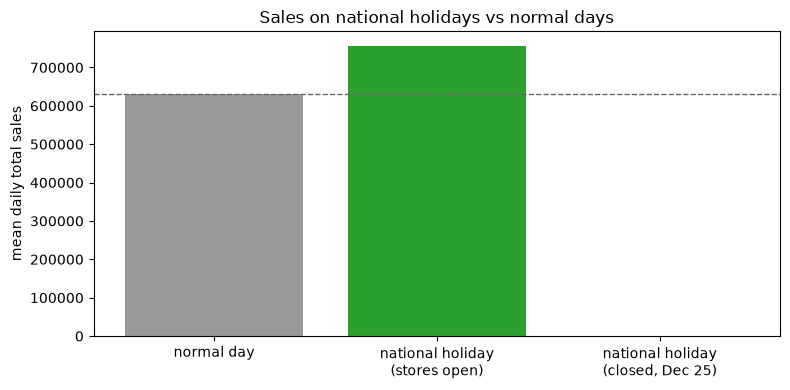

national day-off dates in train span : 82
open national holiday vs normal       : 1.20x  (756,365 vs 631,786)
closed national holidays (Dec 25)     : 4 days, mean sales = 0


In [15]:
# Effect of NATIONAL holidays on total sales. We build the *effective* national day-off
# set: national rows that are a real day off (Holiday / Additional / Bridge / Transfer)
# and were NOT transferred away. 'Work Day' (a forced working day) and 'Event' are excluded.
nat = holidays[(holidays["locale"] == "National")
               & (~holidays["transferred"])
               & (holidays["type"].isin(["Holiday", "Additional", "Bridge", "Transfer"]))]
nat_days = set(nat["date"])

is_holiday = daily_total.index.isin(nat_days)   # numpy bool array aligned to daily_total
is_open = daily_total.values > 0                # Dec 25 (closed) has total sales 0

normal = daily_total[~is_holiday]
open_holi = daily_total[is_holiday & is_open]
closed_holi = daily_total[is_holiday & ~is_open]

labels = ["normal day", "national holiday\n(stores open)", "national holiday\n(closed, Dec 25)"]
means = [normal.mean(), open_holi.mean(), closed_holi.mean()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, means, color=["0.6", "C2", "C3"])
ax.axhline(normal.mean(), color="0.4", ls="--", lw=1)
ax.set_title("Sales on national holidays vs normal days")
ax.set_ylabel("mean daily total sales")
fig.tight_layout()
plt.show()

print(f"national day-off dates in train span : {int(is_holiday.sum())}")
print(f"open national holiday vs normal       : {open_holi.mean() / normal.mean():.2f}x  "
      f"({open_holi.mean():,.0f} vs {normal.mean():,.0f})")
print(f"closed national holidays (Dec 25)     : {len(closed_holi)} days, mean sales = {closed_holi.mean():.0f}")

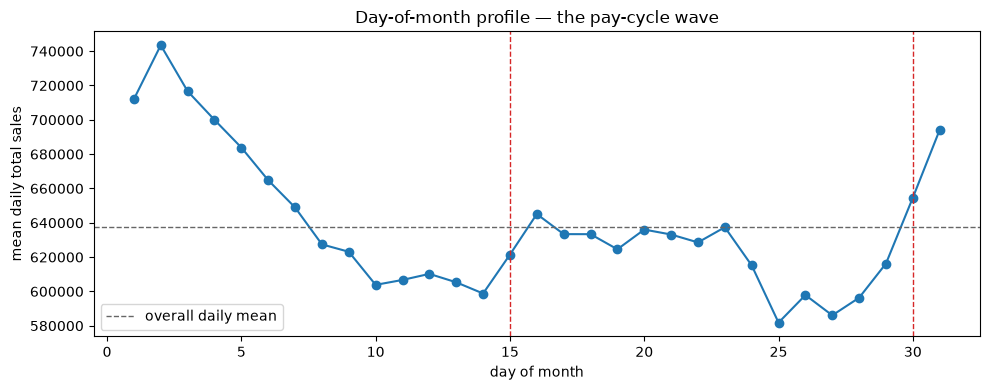

naive payday-flag ratio (15th/month-end vs rest): 1.01
start-of-month surge: day 2 = 743,478  vs  mid-month trough day 14 = 598,778  (1.24x)


In [16]:
# Paydays: public-sector wages are paid on the 15th and the last day of each month.
# A naive "is it payday?" flag barely moves the average — but the day-of-month *profile*
# reveals the real, multi-day pay-cycle wave. We exclude the 4 fully-closed Dec-25 days
# (daily total = 0) so they do not distort the day-25 average.
daily_open = daily_total[daily_total > 0]
dom = daily_open.groupby(daily_open.index.day).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dom.index, dom.values, marker="o", color="C0")
ax.axhline(daily_open.mean(), color="0.4", ls="--", lw=1, label="overall daily mean")
for d in (15, 30):                              # the two paydays
    ax.axvline(d, color="C3", ls="--", lw=1)
ax.set_title("Day-of-month profile — the pay-cycle wave")
ax.set_xlabel("day of month")
ax.set_ylabel("mean daily total sales")
ax.legend()
fig.tight_layout()
plt.show()

# The misleading single-day flag vs the real multi-day surge.
day = daily_open.index.day
is_payday = (day == 15) | daily_open.index.is_month_end
print(f"naive payday-flag ratio (15th/month-end vs rest): "
      f"{daily_open[is_payday].mean() / daily_open[~is_payday].mean():.2f}")
print(f"start-of-month surge: day 2 = {dom[2]:,.0f}  vs  mid-month trough day 14 = {dom[14]:,.0f}  "
      f"({dom[2] / dom[14]:.2f}x)")

**What this tells us / what's next (implications for calendar features):**

- **A holiday is not a yes/no column.** Of 350 rows, **12** are `transferred = True` — the holiday did *not* happen on that listed date — and there are `Bridge` / `Transfer` / `Work Day` rows that move a day off, or even turn a normally-off day *into* a working day. Any holiday feature must first reconcile these into an **effective** holiday calendar; trusting the raw `date` attaches "holiday demand" to the wrong day.
- **Holidays are scoped by locale.** Only **National** holidays apply to all 54 stores; **Regional** (state) and **Local** (city) ones apply to subsets, so their effect is invisible in an all-store total and will need per-store scoping when built as features.
- **Open national holidays lift sales ~20%; a few close the stores entirely.** Mean daily total on open national holidays is ≈ **1.20×** a normal day, while the 4 Christmases sit at **0** (stores shut). *Caveat:* that 1.20 is **suggestive, not exact** — it is not controlled for weekday, and the weekly swing (≈1.39 from Section 4) is larger, so part of the gap is which weekdays the holidays happened to fall on. Holiday flags are clearly worth adding; their precise size is for the model to estimate.
- **The payday signal is a multi-day wave, not a one-day spike.** A naive "is it the 15th or month-end?" flag barely moves the mean (≈ **1.01×** — looks like nothing). But the day-of-month profile (which *does* average out weekday effects) shows a real cycle: a strong **start-of-month surge** (day 2 ≈ 743k vs a mid-month trough ≈ 599k, ≈ **1.24×**) plus a smaller bump just after the 15th. The modeling lesson: encode **days-since-payday / a short post-payday window**, not a single-day flag. (The start-of-month surge is the robust part — it appears every month; the month-end magnitude is noisier since few months have a 31st.)

Next: Section 6 inspects **promotions (`onpromotion`) and the oil price**, including the oil-price gaps and the forward-fill plan.

## Section 6 — Promotions & oil price

Two more supporting signals, with very different reliability:

1. **Promotions** (`onpromotion`) — the count of items on promotion per store/family/day. Crucially it is provided for the **test horizon too** (promotions are planned in advance), so it can be used as a *same-day*, leak-free feature.
2. **Oil price** (`oil.csv`) — Ecuador's economy is oil-dependent, so the WTI price is a plausible macro driver. But the series is full of holes (only trading days, plus blank values) that must be filled *before* it can be a feature.

We check how promotions relate to sales (and why that relationship is hard to size), then look at the oil series and the gap-filling it needs. As before, the aim is to decide *which* signals become features and *how* to use them safely — not to build them here.

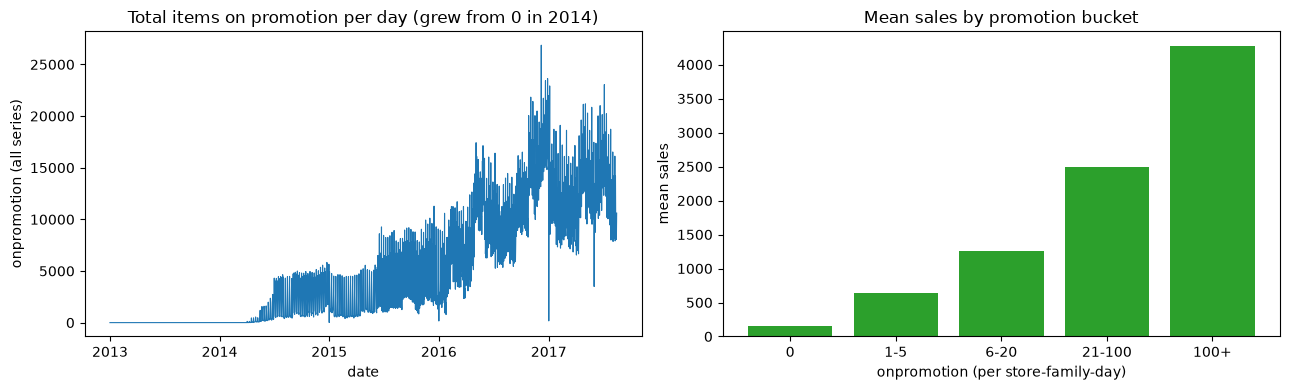

onpromotion present in test?  True | test null values: 0
first day with any promotion : 2014-04-01
share of open rows with onpromotion > 0: 20.4%


In [17]:
import pandas as pd

# Promotions: onpromotion = number of items on promotion for that store/family/day.
# It is present in BOTH train and test (promotions are planned ahead), so it is a
# leak-free, SAME-DAY feature. We look at (1) how it grew over time and (2) how it
# associates with sales — the left plot also exposes why the right one is confounded.
promo_daily = train.groupby("date")["onpromotion"].sum()

open_rows = train_gf[~train_gf["was_closed"]].copy()
open_rows["bucket"] = pd.cut(open_rows["onpromotion"], [-1, 0, 5, 20, 100, 1000],
                             labels=["0", "1-5", "6-20", "21-100", "100+"])
by_bucket = open_rows.groupby("bucket", observed=True)["sales"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(promo_daily.index, promo_daily.values, color="C0", lw=0.8)
ax1.set_title("Total items on promotion per day (grew from 0 in 2014)")
ax1.set_xlabel("date")
ax1.set_ylabel("onpromotion (all series)")
ax2.bar(by_bucket.index.astype(str), by_bucket.values, color="C2")
ax2.set_title("Mean sales by promotion bucket")
ax2.set_xlabel("onpromotion (per store-family-day)")
ax2.set_ylabel("mean sales")
fig.tight_layout()
plt.show()

print("onpromotion present in test? ", "onpromotion" in test.columns,
      "| test null values:", int(test["onpromotion"].isna().sum()))
print("first day with any promotion :", train.loc[train["onpromotion"] > 0, "date"].min().date())
print("share of open rows with onpromotion > 0:", f"{(open_rows['onpromotion'] > 0).mean() * 100:.1f}%")

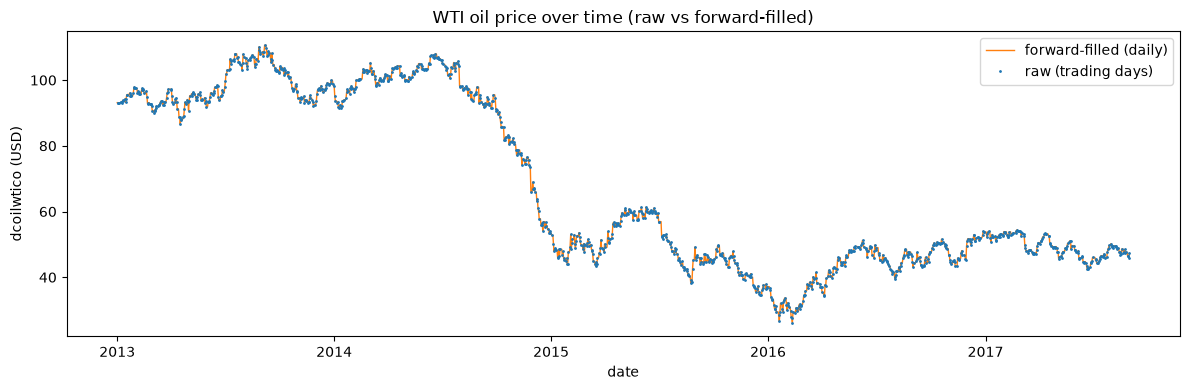

oil rows (trading days only) : 1218
blank prices in those rows   : 43
missing calendar days        : 486
NaN on full daily calendar   : 529  (blanks + missing days)
NaN after ffill + bfill      : 0
oil avg 2014 -> 2016         : 93 -> 43


In [18]:
# Oil price: a candidate macro feature for oil-dependent Ecuador. oil.csv has two kinds of
# holes: (1) only trading days exist (weekends/holidays absent), (2) 43 rows have a blank
# price, including the very first day (2013-01-01). We reindex onto a full daily calendar
# and FORWARD-FILL (carry the last known price) — it only looks backward, so it's leak-free.
# A single back-fill covers the leading blank. Interpolation is rejected: it averages in the
# *future* value and would leak.
full = pd.date_range(oil["date"].min(), oil["date"].max(), freq="D")
o_raw = oil.set_index("date").reindex(full)["dcoilwtico"]
o_filled = o_raw.ffill().bfill()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(o_filled.index, o_filled.values, color="C1", lw=1, label="forward-filled (daily)")
ax.plot(o_raw.index, o_raw.values, color="C0", lw=0, marker=".", ms=2, label="raw (trading days)")
ax.set_title("WTI oil price over time (raw vs forward-filled)")
ax.set_xlabel("date")
ax.set_ylabel("dcoilwtico (USD)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"oil rows (trading days only) : {len(oil)}")
print(f"blank prices in those rows   : {int(oil['dcoilwtico'].isna().sum())}")
print(f"missing calendar days        : {len(full) - len(oil)}")
print(f"NaN on full daily calendar   : {int(o_raw.isna().sum())}  (blanks + missing days)")
print(f"NaN after ffill + bfill      : {int(o_filled.isna().sum())}")
print(f"oil avg 2014 -> 2016         : "
      f"{oil[oil['date'].dt.year == 2014]['dcoilwtico'].mean():.0f} -> "
      f"{oil[oil['date'].dt.year == 2016]['dcoilwtico'].mean():.0f}")

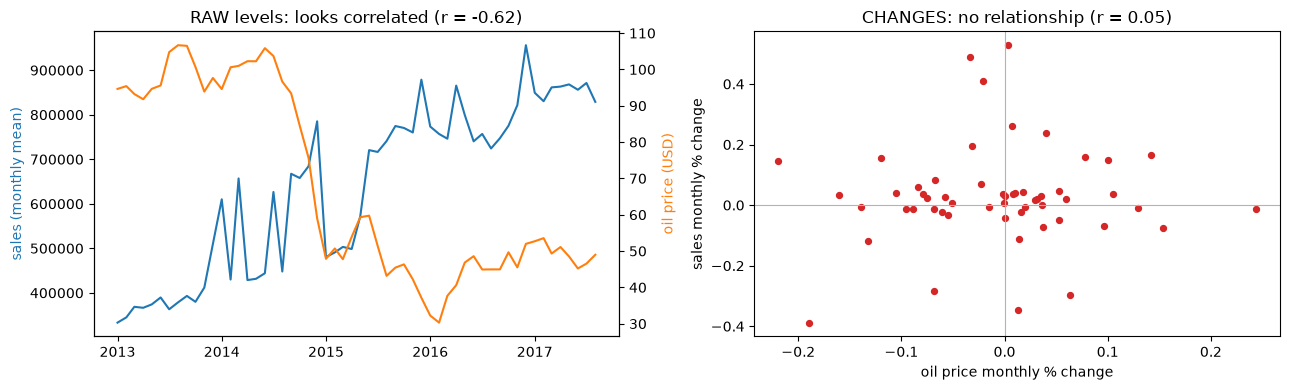

raw daily corr(sales, oil) : -0.62   <- spurious (shared trend)
corr of monthly % changes  : 0.05   <- the honest signal (~0)


In [19]:
# (Bonus) Does oil actually move sales? The RAW correlation is a trap. Oil crashed while
# sales grew over 2013-2017, so the two trends cross and produce a strong NEGATIVE
# correlation that is pure coincidence. The honest test removes the shared trend and asks:
# when oil CHANGES, does sales change with it?
oil_daily = oil.set_index("date").reindex(daily_total.index)["dcoilwtico"].ffill().bfill()

sales_m = daily_total.resample("MS").mean()
oil_m = oil_daily.resample("MS").mean()
raw_corr = daily_total.corr(oil_daily)
change_corr = sales_m.pct_change().corr(oil_m.pct_change())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
# Left: the trap — two trends crossing look strongly (negatively) correlated.
ax1.plot(sales_m.index, sales_m.values, color="C0")
ax1.set_ylabel("sales (monthly mean)", color="C0")
axb = ax1.twinx()
axb.plot(oil_m.index, oil_m.values, color="C1")
axb.set_ylabel("oil price (USD)", color="C1")
ax1.set_title(f"RAW levels: looks correlated (r = {raw_corr:.2f})")
# Right: the honest view — month-over-month CHANGES show no relationship.
ax2.scatter(oil_m.pct_change(), sales_m.pct_change(), s=18, color="C3")
ax2.axhline(0, color="0.7", lw=0.8)
ax2.axvline(0, color="0.7", lw=0.8)
ax2.set_xlabel("oil price monthly % change")
ax2.set_ylabel("sales monthly % change")
ax2.set_title(f"CHANGES: no relationship (r = {change_corr:.2f})")
fig.tight_layout()
plt.show()

print(f"raw daily corr(sales, oil) : {raw_corr:.2f}   <- spurious (shared trend)")
print(f"corr of monthly % changes  : {change_corr:.2f}   <- the honest signal (~0)")

**What this tells us / what's next (implications for promotion & oil features):**

- **`onpromotion` is a strong, leak-free, same-day feature.** It is present in *test* with **no** missing values — promotions are planned ahead — so unlike `transactions` (same dataset, but *not* provided for the horizon → usable only lagged), the promotion count can be fed in directly for the very day being predicted. Sales rise steeply across every promotion bucket.
- **But EDA can't size the promotion lift — it's doubly confounded.** The promo→sales gradient mixes (a) **family/assortment** (big families like GROCERY I both promote more *and* sell more) and (b) **time/trend**: `onpromotion` is structurally **0 before 2014-04-01** and grew alongside the multi-year sales trend, so promotion rows are disproportionately later, higher-trend days. The feature is clearly valuable, but the *magnitude* is for the model to estimate — and it carries **no signal for 2013–early 2014** (all zeros there).
- **Oil needs gap-filling before it's usable.** `oil.csv` has only trading days (**486** calendar days missing) plus **43** blank prices (including the very first day) = **529** holes on a full daily calendar. We **forward-fill** (carry the last known price) — past-only, so leak-free — with a single back-fill for the leading 2013-01-01 blank. *Interpolation is rejected*: it would average in the **future** value and leak.
- **Treat oil as a candidate macro feature, not a proven driver.** The price collapsed across the data window (2014 avg ≈ 93 → 2016 avg ≈ 43) while sales *grew*, so the raw correlation looks strong and negative (≈ **−0.62**) — but that is a pure trend artifact: once both series are detrended (month-over-month changes), the correlation **collapses to ≈ 0**. Oil's ups and downs do *not* track sales' ups and downs at the aggregate level. It may still matter for specific regions/families or with a lag, so whether oil actually helps is for the validation holdout to decide.

Next: Section 7 visualizes **anomalies** — the 2016-04-16 earthquake window and major closures.

## Section 7 — Anomalies

Trend and seasonality describe the *repeating* structure. But the history also contains **one-off
events** that don't repeat — and if we don't mark them, a trend/seasonality model tries to
"explain" them and gets distorted everywhere. Two kinds matter here:

1. **The 2016 earthquake** — a magnitude-7.8 quake on **2016-04-16** set off weeks of relief
   buying. We measure how big and how long the spike actually was.
2. **Major closures** — the days the chain (mostly) shut, which show up as the lowest-sales days.

The aim is to decide how the model should *treat* these: which become a **flag**, and which are
already covered by the calendar features from earlier sections.

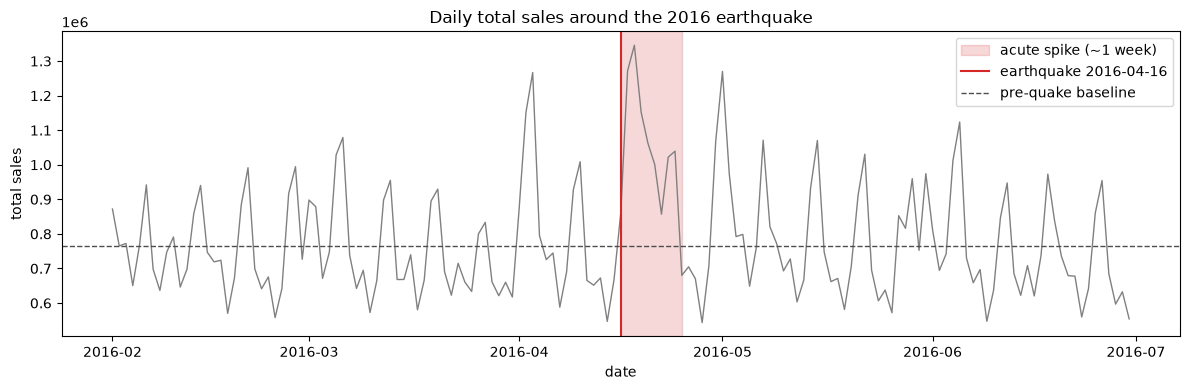

pre-quake baseline (8 wks) : 764,910
week +0 (relief spike)     : 1,078,933  (1.41x)
week +1 (already normal)   : 766,950  (1.00x)
peak day                   : 2016-04-18  1,345,921  (1.76x)


In [20]:
# The 2016-04-16 earthquake (magnitude 7.8) triggered a burst of relief buying (water,
# food, supplies) — a ONE-OFF shock, not a repeating pattern. We zoom into early 2016 and
# compare against an 8-week pre-quake baseline (8 full weeks keeps the weekday mix balanced).
eq = pd.Timestamp("2016-04-16")
win = daily_total[(daily_total.index >= "2016-02-01") & (daily_total.index <= "2016-06-30")]
baseline = daily_total[(daily_total.index >= eq - pd.Timedelta(days=56))
                       & (daily_total.index < eq)].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(win.index, win.values, color="0.5", lw=1)
ax.axvspan(eq, eq + pd.Timedelta(days=9), color="C3", alpha=0.18, label="acute spike (~1 week)")
ax.axvline(eq, color="C3", lw=1.5, label="earthquake 2016-04-16")
ax.axhline(baseline, color="0.3", ls="--", lw=1, label="pre-quake baseline")
ax.set_title("Daily total sales around the 2016 earthquake")
ax.set_xlabel("date")
ax.set_ylabel("total sales")
ax.legend()
fig.tight_layout()
plt.show()

wk0 = win[(win.index >= eq) & (win.index < eq + pd.Timedelta(days=7))].mean()
wk1 = win[(win.index >= eq + pd.Timedelta(days=7)) & (win.index < eq + pd.Timedelta(days=14))].mean()
peak = win[(win.index >= eq) & (win.index < eq + pd.Timedelta(days=21))]
print(f"pre-quake baseline (8 wks) : {baseline:,.0f}")
print(f"week +0 (relief spike)     : {wk0:,.0f}  ({wk0 / baseline:.2f}x)")
print(f"week +1 (already normal)   : {wk1:,.0f}  ({wk1 / baseline:.2f}x)")
print(f"peak day                   : {peak.idxmax().date()}  {peak.max():,.0f}  ({peak.max() / baseline:.2f}x)")

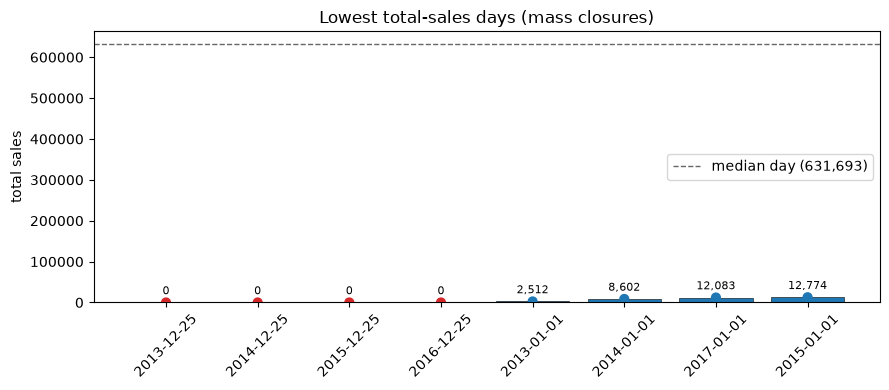

red  = Dec 25 — sales exactly 0 (fully closed), were missing rows restored in Section 2
blue = Jan 1  — recorded near-zero days (stores barely open)


In [21]:
# Major closures: the days the chain (mostly) shut. The lowest total-sales days are the
# 4 Christmases (sales = 0 — these were MISSING rows we restored in Section 2) and the
# 4 New Year's Days (recorded, but near-zero — stores barely open).
# NOTE: the Dec-25 bars have height 0, so we add value labels + dots to make them visible.
lowest = daily_total.nsmallest(8).sort_values()
labels = [d.strftime("%Y-%m-%d") for d in lowest.index]
colors = ["C3" if d.month == 12 else "C0" for d in lowest.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, lowest.values, color=colors, edgecolor="black", linewidth=0.4)
ax.scatter(range(len(lowest)), lowest.values, color=colors, s=40, zorder=3)  # dots show 0-height bars
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in lowest.values], padding=4, fontsize=8)
ax.axhline(daily_total.median(), color="0.4", ls="--", lw=1, label=f"median day ({daily_total.median():,.0f})")
ax.set_title("Lowest total-sales days (mass closures)")
ax.set_ylabel("total sales")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
plt.show()

print("red  = Dec 25 — sales exactly 0 (fully closed), were missing rows restored in Section 2")
print("blue = Jan 1  — recorded near-zero days (stores barely open)")

**What this tells us / what's next (implications for anomaly handling):**

- **The 2016 earthquake is a one-off shock, not a pattern.** In the **first week** daily sales jumped to ≈ **1.41×** the pre-quake baseline (peak ≈ **1.76×** on 2016-04-18, the Monday after the Saturday quake) as people bought relief supplies — then **week +1 was already back to normal**. The acute spike lasts about a week, not weeks.
- **Beware reading routine calendar effects as an "earthquake echo."** Sales two weeks out (late-April / early-May) look elevated, but that window is just the **start-of-month payday surge** (Section 5) plus **May 1 Labour Day** (a national holiday) — the *same* calendar week is actually *higher* in 2017 (no quake) than in 2016, confirming it is the regular pattern, not a lingering quake effect. (Same trap as the spurious oil correlation: don't attribute a routine pattern to a special event.)
- **Label anomalies, don't delete them.** Dropping the spike rows would punch a hole back into the gap-free calendar from Section 2 (and discard real data). The plan is an **earthquake-window flag** — a deliberately generous envelope (≈ 2016-04-16 to mid-May) so the model can absorb the shock as a known event — even though the *measured* acute spike is ≈ 1 week.
- **Closures are calendar-driven and already handled.** The only true *gaps* are the 4 Dec 25 closures (sales = 0), restored in Section 2; the 4 New Year's Days are *recorded* near-zero days (stores barely open), which the Section 5 calendar features already cover — no special treatment needed.

Next: Section 8 pulls every section's finding together into a short **implications-for-modeling** summary that drives the modeling stages.

## Section 8 — Implications for modeling

This closing section distills the whole notebook into the decisions that drive the modeling work. Nothing here is new — each point is a one-line consequence of a finding established and verified above. Read it as the bridge from *understanding the data* to *building the forecast*.

### From evidence to decisions

Every row traces back to a section above — the EDA exists so each modeling choice is *motivated by data*, not guessed.

| What the data showed | What we'll do about it |
|---|---|
| Closed days are **absent, not zero** (§2) | Reindex to a gap-free daily calendar with a `was_closed` flag **before** any feature, so lags and Fourier terms count days correctly |
| **Strong, decelerating growth**; families on wildly different scales (§3) | An explicit **trend** term (allow mild curvature); model **per series** in **`log1p`** space so small families aren't swamped |
| **Dominant weekly cycle** (weekend ≈1.39× weekdays, Sunday peak) with a 3.5-day harmonic (§4) | ~**2–3 weekly** Fourier harmonics |
| **Smooth annual cycle**, December peak (§4) | ~**3–5 annual** Fourier harmonics — but leave the *sharp* December spike to holiday features |
| Holidays are **not yes/no** and are **locale-scoped** (§5) | Build an **effective holiday calendar** (reconcile transferred / bridge / work-day) and scope National / Regional / Local per store |
| Payday is a **multi-day wave**, not a one-day spike (§5) | Encode **days-since-payday / a post-payday window**, not an `is_payday` flag |
| `onpromotion` is **known for the horizon** (§6) | Use it **same-day, leak-free** — a strong predictor |
| `transactions` **stops at the train end** — no horizon coverage (§1 span table) | Use it **lag-only**, never same-day |
| Oil has gaps; its sales effect is **spurious via trend** (§6) | **Forward-fill** (past-only, no interpolation); include only as a *candidate* feature to test — expect it weak |
| 2016 earthquake = **one-off ≈1-week spike** (§7) | An **earthquake-window flag** — *label, don't delete* |

**Rules that keep us honest** (carried through every stage): score with **RMSLE in log space**, **clip predictions ≥ 0**, validate on a **single time-respecting 16-day holdout** (no random folds), keep a **seasonal-naive / near-zero fallback** so every one of the 28,512 rows always gets a value, and **log each iteration's RMSLE** so we can see what actually helped.

**The modeling roadmap this points to:**

1. **Baseline** — seasonal-naive (same weekday, prior week) → the first RMSLE bar to beat.
2. **Deterministic** — trend + weekly/annual Fourier seasonality.
3. **+ Calendar features** — effective holidays, payday window, earthquake flag.
4. **+ Serial dependence & drivers** — sales **lags that clear the 16-day horizon** (direct forecasting), `onpromotion` same-day, transactions/oil lagged; then a **hybrid** ML model on the residuals.

Each step is scored on the *same* holdout, and we keep whatever lowers RMSLE — including the empirical global-vs-per-group model choice.